# Sentiment analysis
This notebook contains an exploratory comparison and test of different sentiment analysis approaches on a sample of the SPoRC dataset to be used for the final analysis in the main notenbook.

In [12]:
# Dependencies

# Sentence segmentation
import spacy
nlp = spacy.load("en_core_web_sm")

# HuggingFace for RoBERTa
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F

# VADER
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
vader = SentimentIntensityAnalyzer()

# Data handling
import pandas as pd
import numpy as np
from tqdm import tqdm

In [13]:
# Helpers

def split_into_sentences(text: str):
    """
    Split text into sentences using spaCy.
    Returns a list of sentence strings.
    """
    doc = nlp(text)
    return [sent.text.strip() for sent in doc.sents if sent.text.strip()]

In [14]:
from helpers.sporc import (
    SPORCDataset,
    get_all_categories,
    get_main_categories,
    get_subcategories_list,
    is_main_category,
    is_subcategory,
    is_valid_category,
)
from pprint import pprint

sporc = SPORCDataset(local_data_dir="data", load_samples_only=True)

INFO:helpers.sporc.dataset:Loading SPORC dataset from local directory: data
INFO:helpers.sporc.dataset:Loading SPORC sample dataset only.
INFO:helpers.sporc.dataset:✓ All required files found
INFO:helpers.sporc.dataset:Loading all records from local files into memory...
INFO:helpers.sporc.dataset:Loading episode_data_sample...
INFO:helpers.sporc.dataset:Loading speaker_turn_data_sample...
INFO:helpers.sporc.dataset:✓ Loaded 210,000 total records from 2 files
INFO:helpers.sporc.dataset:✓ Local dataset loaded successfully in 6.29 seconds
INFO:helpers.sporc.dataset:✓ Dataset loaded successfully with 210000 total records
INFO:helpers.sporc.dataset:Processing dataset into Podcast and Episode objects...
INFO:helpers.sporc.dataset:Separating episode data from speaker turn data...


Loading episodes:   0%|          | 0/210000 [00:00<?, ?it/s]

INFO:helpers.sporc.dataset:✓ Separation completed in 0.25 seconds
INFO:helpers.sporc.dataset:  Episode records: 10,000, Speaker turn records: 200,000
INFO:helpers.sporc.dataset:Grouping episodes by podcast...
INFO:helpers.sporc.dataset:✓ Grouping completed in 0.04 seconds
INFO:helpers.sporc.dataset:  Episodes grouped into 1826 podcasts
INFO:helpers.sporc.dataset:Creating Podcast and Episode objects...
INFO:helpers.sporc.dataset:✓ Object creation completed in 0.60 seconds
INFO:helpers.sporc.dataset:Loading speaker turn data for episodes...
INFO:helpers.sporc.dataset:Loading turn data for 200,000 speaker turn records...
INFO:helpers.sporc.dataset:Grouping turns by episode URL...
INFO:helpers.sporc.dataset:✓ Turn grouping completed in 0.13 seconds
INFO:helpers.sporc.dataset:  Turns grouped into 1,033 episodes
INFO:helpers.sporc.dataset:Loading turns for each episode...
INFO:helpers.sporc.dataset:✓ Turn loading completed in 2.84 seconds
INFO:helpers.sporc.dataset:  Episodes with turns: 1,0

In [33]:
# Get all episodes
episodes = sporc.get_all_episodes()
print(f"Loaded {len(episodes)} episodes from SPoRC.")

# Get subset of episodes (too slow for initial work otherwise)
import random
random.seed(42)
episodes = random.sample(episodes, 100)
print(f"Using {len(episodes)} random episodes for analysis.")

# Helper to pick a main "genre" label for an episode
all_main_categories = set(get_main_categories())

def get_episode_genre(ep):
    """
    Choose a single genre label for the episode.
    Strategy:
      1. If any category is a main category, use the first one.
      2. Otherwise, fall back to the first category if present.
      3. Else return None.
    """
    if getattr(ep, "categories", None):
        mains = [c for c in ep.categories if c in all_main_categories]
        if mains:
            return mains[0]
        return ep.categories[0]
    return None

rows = []

for ep_idx, episode in enumerate(tqdm(episodes, desc="Building sentence table")):
    genre = get_episode_genre(episode)
    turns = episode.get_all_turns()  # list of Turn objects

    sentence_idx = 0  # sentence index within this episode

    for turn in turns:
        text = getattr(turn, "text", None)
        if not text or not text.strip():
            continue

        # Sentence segmentation
        sentences = split_into_sentences(text)

        for sent in sentences:
            if not sent.strip():
                continue

            rows.append(
                {
                    "episode_index": ep_idx,                    # index in our list
                    "episode_title": episode.title,
                    "episode_date": getattr(episode, "episode_date", None),
                    "genre": genre,
                    "categories": episode.categories,
                    "speaker": getattr(turn, "primary_speaker", None),
                    "is_host_turn": getattr(turn, "is_host", None)
                    if hasattr(turn, "is_host")
                    else None,
                    "sentence": sent,
                    "sentence_idx": sentence_idx,              # for episode-relative time
                    "turn_word_count": getattr(turn, "word_count", None),
                    "turn_duration": getattr(turn, "duration", None),
                }
            )
            sentence_idx += 1

# Create the main sentences dataframe
sentences_df = pd.DataFrame(rows)
print(f"\nSentence-level table created with {len(sentences_df)} rows.")
print(sentences_df.head(6))

Loaded 10000 episodes from SPoRC.
Using 100 random episodes for analysis.


Building sentence table: 100%|██████████| 100/100 [00:18<00:00,  5.36it/s]


Sentence-level table created with 6378 rows.
   episode_index                                  episode_title  \
0              1  Dawain's SideBAR Why You Need A Podcast Coach   
1              1  Dawain's SideBAR Why You Need A Podcast Coach   
2              1  Dawain's SideBAR Why You Need A Podcast Coach   
3              1  Dawain's SideBAR Why You Need A Podcast Coach   
4              1  Dawain's SideBAR Why You Need A Podcast Coach   
5              1  Dawain's SideBAR Why You Need A Podcast Coach   

         episode_date   genre                         categories     speaker  \
0 2020-06-19 06:00:00  health  [health, fitness, , , , , , , , ]  SPEAKER_00   
1 2020-06-19 06:00:00  health  [health, fitness, , , , , , , , ]  SPEAKER_00   
2 2020-06-19 06:00:00  health  [health, fitness, , , , , , , , ]  SPEAKER_00   
3 2020-06-19 06:00:00  health  [health, fitness, , , , , , , , ]  SPEAKER_00   
4 2020-06-19 06:00:00  health  [health, fitness, , , , , , , , ]  SPEAKER_00   
5 20

In [34]:
# Load Siebert sentiment model and score sentences 

model_name = "siebert/sentiment-roberta-large-english"

# Load tokenizer & model (uses safetensors by default)
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    trust_remote_code=True, 
    use_safetensors=True
)
model.eval()

# Label mapping for Siebert:
# 0 = negative
# 1 = positive
label_mapping = {0: "negative", 1: "positive"}

def score_siebert(sentences, batch_size=32, max_length=256):
    """
    Compute sentiment polarity + intensity using the Siebert model.
    Returns:
        - list of 'positive'/'negative' polarity labels
        - list of intensities (probability of predicted class)
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    polarities = []
    intensities = []

    for i in tqdm(range(0, len(sentences), batch_size), desc="Siebert sentiment"):
        batch = sentences[i:i+batch_size]

        enc = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = model(**enc)
            logits = outputs.logits
            probs = F.softmax(logits, dim=-1)

        preds = torch.argmax(probs, dim=1).cpu().numpy()
        confs = torch.max(probs, dim=1).values.cpu().numpy()

        polarities.extend([label_mapping[p] for p in preds])
        intensities.extend(confs)

    return polarities, intensities


# Run Siebert on dataset

sentences_list = sentences_df["sentence"].tolist()

siebert_polarity, siebert_intensity = score_siebert(sentences_list)

sentences_df["polarity"] = siebert_polarity      # replaces roberta_polarity
sentences_df["intensity"] = siebert_intensity    # replaces roberta_intensity

print("Siebert sentiment columns added to sentences_df.")
sentences_df.head()


Siebert sentiment: 100%|██████████| 200/200 [20:38<00:00,  6.19s/it]

Siebert sentiment columns added to sentences_df.


,episode_index,episode_title,episode_date,genre,categories,speaker,is_host_turn,sentence,sentence_idx,turn_word_count,turn_duration,polarity,intensity
0,1,Dawain's SideBAR Why You Need A Podcast Coach,2020-06-19 06:00:00,health,"[health, fitness, , , , , , , , ]",SPEAKER_00,False,(upbeat music) -,0,734,321.38,positive,0.997787
1,1,Dawain's SideBAR Why You Need A Podcast Coach,2020-06-19 06:00:00,health,"[health, fitness, , , , , , , , ]",SPEAKER_00,False,"Welcome to season three of ""Dwayne Sidebar.""",1,734,321.38,positive,0.998331
2,1,Dawain's SideBAR Why You Need A Podcast Coach,2020-06-19 06:00:00,health,"[health, fitness, , , , , , , , ]",SPEAKER_00,False,"This is a sidebar from the original show, the ...",2,734,321.38,positive,0.990639
3,1,Dawain's SideBAR Why You Need A Podcast Coach,2020-06-19 06:00:00,health,"[health, fitness, , , , , , , , ]",SPEAKER_00,False,"We're just me just talking to you, whether it'...",3,734,321.38,positive,0.998547
4,1,Dawain's SideBAR Why You Need A Podcast Coach,2020-06-19 06:00:00,health,"[health, fitness, , , , , , , , ]",SPEAKER_00,False,I hope you guys enjoy this show.,4,734,321.38,positive,0.998877


In [35]:
# Run VADER sentiment scoring as alternative for comparison to RoBERTa scoring
def score_vader(sentences):
    """
    Apply VADER to a list of sentences.
    Returns:
      - vader_score: compound score ∈ [-1, 1]
      - vader_polarity: negative / neutral / positive
    """
    scores = []
    labels = []

    for sent in tqdm(sentences, desc="VADER sentiment"):
        vs = vader.polarity_scores(sent)
        compound = vs["compound"]

        # Polarity thresholds from the VADER paper
        if compound >= 0.05:
            label = "positive"
        elif compound <= -0.05:
            label = "negative"
        else:
            label = "neutral"

        scores.append(compound)
        labels.append(label)

    return scores, labels


# --- Run VADER on your sentences_df ---

vader_scores, vader_polarity = score_vader(sentences_df["sentence"].tolist())

sentences_df["vader_score"] = vader_scores
sentences_df["vader_polarity"] = vader_polarity

print("VADER sentiment columns added to sentences_df.")
sentences_df.head()

VADER sentiment: 100%|██████████| 6378/6378 [00:00<00:00, 26325.43it/s]

VADER sentiment columns added to sentences_df.


,episode_index,episode_title,episode_date,genre,categories,speaker,is_host_turn,sentence,sentence_idx,turn_word_count,turn_duration,polarity,intensity,vader_score,vader_polarity
0,1,Dawain's SideBAR Why You Need A Podcast Coach,2020-06-19 06:00:00,health,"[health, fitness, , , , , , , , ]",SPEAKER_00,False,(upbeat music) -,0,734,321.38,positive,0.997787,0.0000,neutral
1,1,Dawain's SideBAR Why You Need A Podcast Coach,2020-06-19 06:00:00,health,"[health, fitness, , , , , , , , ]",SPEAKER_00,False,"Welcome to season three of ""Dwayne Sidebar.""",1,734,321.38,positive,0.998331,0.4588,positive
2,1,Dawain's SideBAR Why You Need A Podcast Coach,2020-06-19 06:00:00,health,"[health, fitness, , , , , , , , ]",SPEAKER_00,False,"This is a sidebar from the original show, the ...",2,734,321.38,positive,0.990639,0.3182,positive
3,1,Dawain's SideBAR Why You Need A Podcast Coach,2020-06-19 06:00:00,health,"[health, fitness, , , , , , , , ]",SPEAKER_00,False,"We're just me just talking to you, whether it'...",3,734,321.38,positive,0.998547,0.0000,neutral
4,1,Dawain's SideBAR Why You Need A Podcast Coach,2020-06-19 06:00:00,health,"[health, fitness, , , , , , , , ]",SPEAKER_00,False,I hope you guys enjoy this show.,4,734,321.38,positive,0.998877,0.7269,positive


In [20]:
# Episode-level sentiment time series (normalized 0–1 based on episode progress out of full episode elapsed time)

# Make a copy to avoid accidental modification
ts_df = sentences_df.copy()

# -------------------------
# 1. Normalize sentence_idx per episode
# -------------------------
def normalize_episode_progress(df):
    """
    Adds an `episode_progress` column scaled to [0, 1] for each episode.
    """
    df = df.sort_values(["episode_index", "sentence_idx"])
    
    df["episode_progress"] = (
        df.groupby("episode_index")["sentence_idx"]
        .transform(lambda x: x / x.max() if x.max() > 0 else 0)
    )
    return df

ts_df = normalize_episode_progress(ts_df)

# -------------------------
# 2. Convert categorical polarity → numeric values for plotting
# -------------------------

polarity_map = {
    "negative": -1,
    "neutral": 0,
    "positive": 1
}

ts_df["roberta_num"] = ts_df["roberta_polarity"].map(polarity_map)
ts_df["vader_num"] = ts_df["vader_polarity"].map(polarity_map)

# -------------------------
# 3. OPTIONAL: Smooth the signals (rolling window)
#    This reduces noise for plotting.
# -------------------------

def smooth_episode(df, window=25):
    """
    Applies a rolling mean smoothing within each episode.
    """
    df = df.sort_values(["episode_index", "sentence_idx"])
    df["roberta_smooth"] = (
        df.groupby("episode_index")["roberta_num"]
        .transform(lambda x: x.rolling(window, min_periods=1, center=True).mean())
    )
    df["vader_smooth"] = (
        df.groupby("episode_index")["vader_num"]
        .transform(lambda x: x.rolling(window, min_periods=1, center=True).mean())
    )
    return df

ts_df = smooth_episode(ts_df, window=25)

# -------------------------
# 4. Finalize episode time-series dataframe
# -------------------------

episode_timeseries_df = ts_df[
    [
        "episode_index",
        "episode_title",
        "genre",
        "episode_progress",
        "sentence",
        "sentence_idx",
        "roberta_num",
        "roberta_intensity",
        "roberta_smooth",
        "vader_num",
        "vader_score",
        "vader_smooth",
    ]
]

print("Episode-level time series dataframe created.")
episode_timeseries_df.head()


Episode-level time series dataframe created.


,episode_index,episode_title,genre,episode_progress,sentence,sentence_idx,roberta_num,roberta_intensity,roberta_smooth,vader_num,vader_score,vader_smooth
0,1,Dawain's SideBAR Why You Need A Podcast Coach,health,0.000000,(upbeat music) -,0,0,0.878926,0.230769,0,0.0000,0.307692
1,1,Dawain's SideBAR Why You Need A Podcast Coach,health,0.004274,"Welcome to season three of ""Dwayne Sidebar.""",1,1,0.546142,0.214286,1,0.4588,0.285714
2,1,Dawain's SideBAR Why You Need A Podcast Coach,health,0.008547,"This is a sidebar from the original show, the ...",2,0,0.916921,0.200000,1,0.3182,0.266667
3,1,Dawain's SideBAR Why You Need A Podcast Coach,health,0.012821,"We're just me just talking to you, whether it'...",3,0,0.611578,0.187500,0,0.0000,0.312500
4,1,Dawain's SideBAR Why You Need A Podcast Coach,health,0.017094,I hope you guys enjoy this show.,4,1,0.978630,0.235294,1,0.7269,0.294118


In [22]:
# Visualization of sentiment Time Series 

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.1)

# Plot sentiment for a single episode

def plot_episode_sentiment(df, episode_index, model="roberta", smooth=True):
    """
    Plot sentiment time series for one episode.
    model ∈ {"roberta", "vader"}
    """
    assert model in ["roberta", "vader"]

    ep = df[df["episode_index"] == episode_index]

    if ep.empty:
        print("Episode not found.")
        return

    title = ep["episode_title"].iloc[0]
    genre = ep["genre"].iloc[0]

    if model == "roberta":
        y = ep["roberta_smooth"] if smooth else ep["roberta_num"]
        label = "RoBERTa Sentiment"
    else:
        y = ep["vader_smooth"] if smooth else ep["vader_num"]
        label = "VADER Sentiment"

    plt.figure(figsize=(12, 4))
    plt.plot(ep["episode_progress"], y, label=label, alpha=0.9)
    plt.title(f"Sentiment Curve — Episode: {title} ({genre})")
    plt.xlabel("Episode Progress (0–1)")
    plt.ylabel("Sentiment")
    plt.ylim(-1.1, 1.1)
    plt.legend()
    plt.show()


# Plot average sentiment curve per genre

def plot_genre_average(df, model="roberta", smooth=True):
    """
    Compute and plot the average sentiment curve for each genre.
    model ∈ {"roberta", "vader"}
    """
    assert model in ["roberta", "vader"]

    if model == "roberta":
        y_col = "roberta_smooth" if smooth else "roberta_num"
    else:
        y_col = "vader_smooth" if smooth else "vader_num"

    # Bin progress into percent buckets
    df["progress_bin"] = (df["episode_progress"] * 100).astype(int)

    grouped = (
        df.groupby(["genre", "progress_bin"])[y_col]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(14, 6))

    genres = grouped["genre"].unique()

    for g in genres:
        sub = grouped[grouped["genre"] == g]
        plt.plot(sub["progress_bin"], sub[y_col], label=g, alpha=0.8)

    plt.title(f"Average Sentiment Curve by Genre ({model})")
    plt.xlabel("Episode Progress (%)")
    plt.ylabel("Average Sentiment")
    plt.ylim(-1.1, 1.1)
    plt.legend(title="Genre", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


# Distribution of polarity per genre

def plot_sentiment_distribution(df, model="roberta"):
    """
    Plot the distribution of polarity (numeric) per genre.
    """
    assert model in ["roberta", "vader"]

    y_col = "roberta_num" if model == "roberta" else "vader_num"

    plt.figure(figsize=(12, 6))
    sns.boxplot(
        data=df,
        x="genre",
        y=y_col,
        palette="Set2"
    )
    plt.xticks(rotation=45)
    plt.title(f"Sentiment Distribution by Genre ({model})")
    plt.ylabel("Sentiment Polarity (-1,0,1)")
    plt.show()


# Compare RoBERTa and VADER for an episode

def plot_episode_comparison(df, episode_index, smooth=True):
    """
    Plot both RoBERTa and VADER curves for the same episode.
    """
    ep = df[df["episode_index"] == episode_index]

    if ep.empty:
        print("Episode not found.")
        return

    title = ep["episode_title"].iloc[0]
    genre = ep["genre"].iloc[0]

    r = ep["roberta_smooth"] if smooth else ep["roberta_num"]
    v = ep["vader_smooth"] if smooth else ep["vader_num"]

    plt.figure(figsize=(12, 4))
    plt.plot(ep["episode_progress"], r, label="RoBERTa", alpha=0.9)
    plt.plot(ep["episode_progress"], v, label="VADER", alpha=0.7)
    plt.title(f"Sentiment Comparison — Episode: {title} ({genre})")
    plt.xlabel("Episode Progress (0–1)")
    plt.ylabel("Sentiment")
    plt.ylim(-1.1, 1.1)
    plt.legend()
    plt.show()


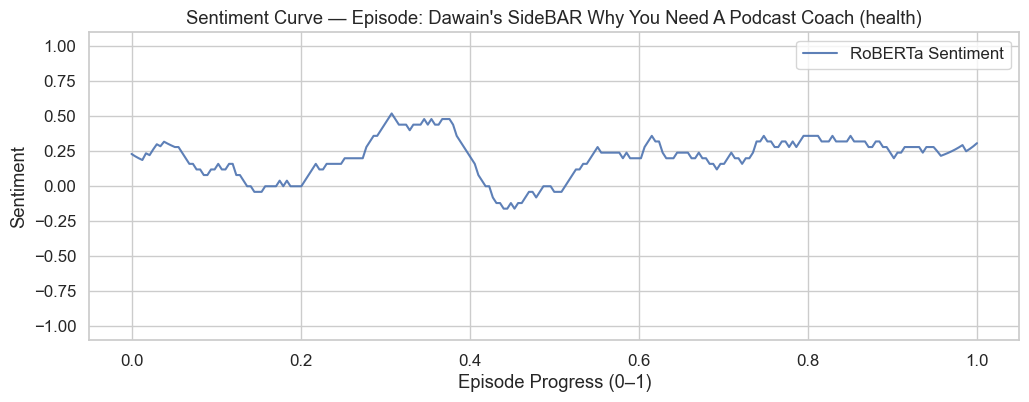

In [24]:
plot_episode_sentiment(episode_timeseries_df, episode_index=1)

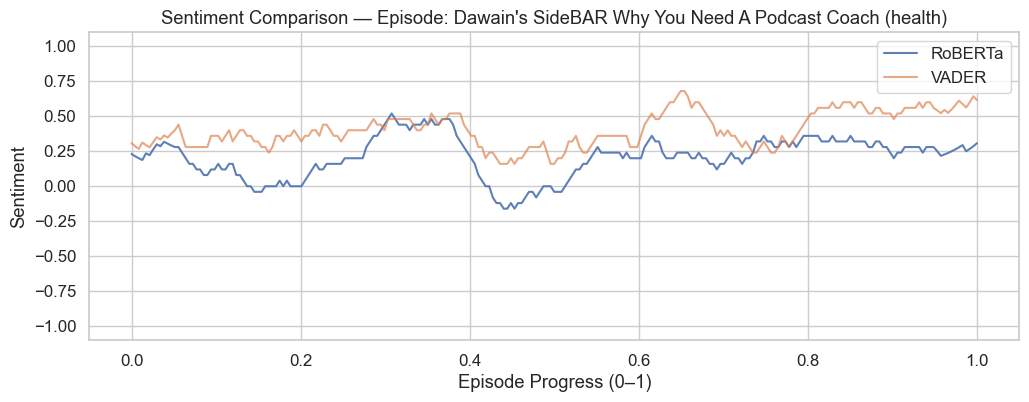

In [25]:
plot_episode_comparison(episode_timeseries_df, episode_index=1)

/var/folders/7b/z9f_qyjd6459ffds1s99zztr0000gn/T/ipykernel_82700/4045977173.py:58: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["progress_bin"] = (df["episode_progress"] * 100).astype(int)


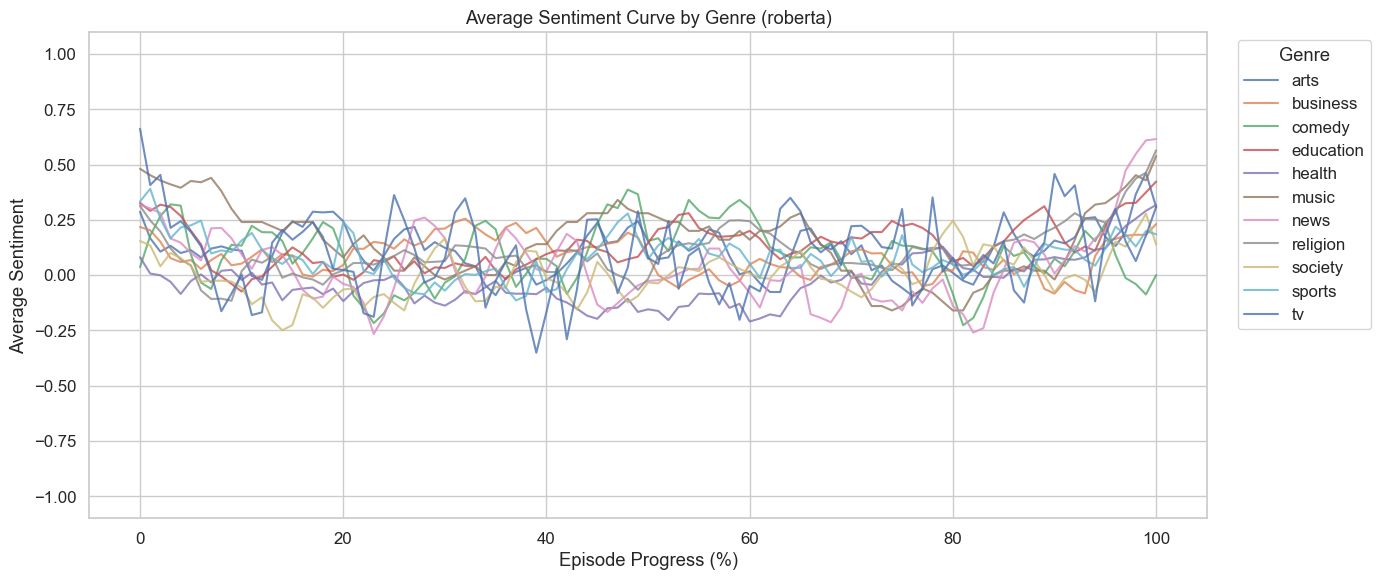

In [26]:
plot_genre_average(episode_timeseries_df, model="roberta")

/var/folders/7b/z9f_qyjd6459ffds1s99zztr0000gn/T/ipykernel_82700/4045977173.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


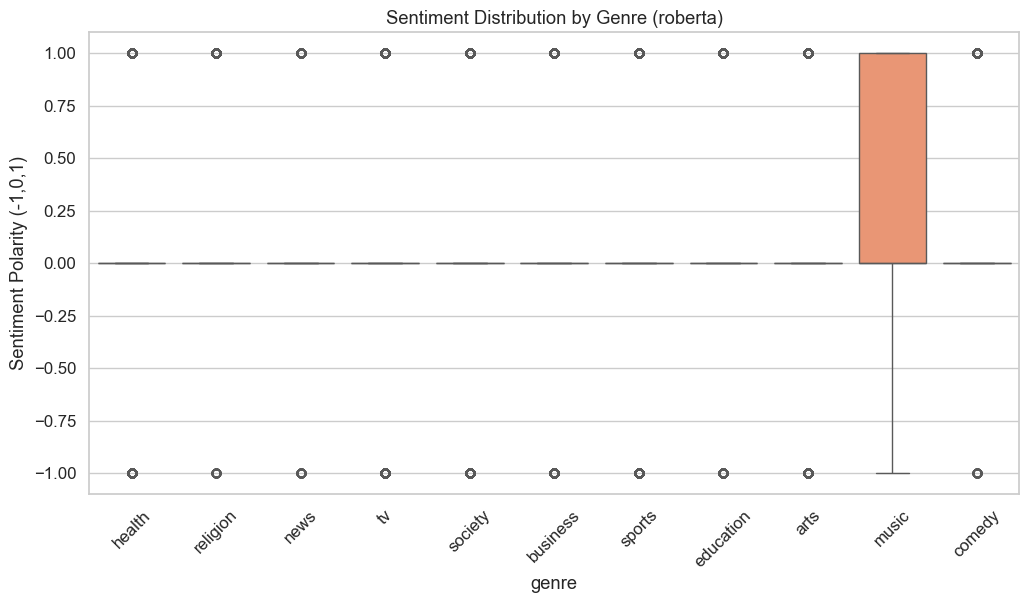

In [27]:
plot_sentiment_distribution(episode_timeseries_df, model="roberta")

In [30]:
print(episode_timeseries_df["roberta_num"].value_counts(normalize=True))
print(episode_timeseries_df.groupby("genre")["roberta_num"].mean())

roberta_num
 0    0.683072
 1    0.189965
-1    0.126963
Name: proportion, dtype: float64
genre
arts         0.112182
business     0.085286
comedy       0.097892
education    0.133203
health      -0.032918
music        0.160622
news         0.036624
religion     0.104110
society     -0.000333
sports       0.081462
tv           0.095136
Name: roberta_num, dtype: float64
